In [19]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.sql.types import *
from pyspark.sql.window import Window
from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler, StandardScaler, StringIndexer, OneHotEncoder
from pyspark.ml.classification import LogisticRegression, RandomForestClassifier, GBTClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator, BinaryClassificationEvaluator
from pyspark.sql.functions import skewness, kurtosis, stddev, mean, expr
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os
import psutil
import builtins

total_ram_gb = psutil.virtual_memory().total / 1e9
print(f"Total system RAM: {total_ram_gb:.1f} GB")
driver_mem_gb = builtins.max(4, builtins.min(10, int(total_ram_gb * 0.5)))
print(f"Setting spark.driver.memory to {driver_mem_gb}g")

spark = (
    SparkSession.builder
    .appName("BusReliabilityYorkshire")
    .master("local[4]")                                           
    .config("spark.driver.memory", f"{driver_mem_gb}g")
    .config("spark.sql.adaptive.enabled", "true")
    .config("spark.sql.adaptive.coalescePartitions.enabled", "true")
    .config("spark.sql.shuffle.partitions", "32")                  
    .config("spark.serializer", "org.apache.spark.serializer.KryoSerializer")
    .config("spark.memory.fraction", "0.8")
    .config("spark.memory.storageFraction", "0.3")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("WARN")
print(f"Spark Session created: {spark.version}")
print("Spark UI:           ", spark.sparkContext.uiWebUrl, " <-- screenshot this while a job runs")


Total system RAM: 17.2 GB
Setting spark.driver.memory to 8g
Spark Session created: 4.1.1
Spark UI:            http://192.168.111.15:4040  <-- screenshot this while a job runs


In [20]:
def explore_dataset(df, name):
    print(f"\n{'='*50}")
    print(f"Exploring: {name}")
    print(f"{'='*50}")
    count = df.count()
    print(f"Total records: {count:,}")
    print("\nSchema:")
    df.printSchema()
    print("\nSample data (5 rows):")
    df.show(5, truncate=False)
    print("\nNull values per column:")
    null_counts = df.select([sum(col(c).isNull().cast("int")).alias(c) for c in df.columns])
    null_counts.show()
    numeric_cols = [c for c, t in df.dtypes if t in ("int", "double", "float", "long")]
    if numeric_cols:
        print("\nSummary statistics for numeric columns:")
        df.select(numeric_cols).describe().show()

In [21]:
# ============================================
# 2. DATA LOADING
# ============================================
def load_gtfs_data(base_path):
    """
    Load all GTFS files from the specified directory
    """
    print("Loading GTFS files...")
 
    # Load each GTFS file (short name -> path)
    files = {
        'agency': f"/Users/paridhi/Downloads/itm_yorkshire_gtfs/agency.txt",
        'calendar': f"/Users/paridhi/Downloads/itm_yorkshire_gtfs/calendar.txt",
        'calendar_dates': f"/Users/paridhi/Downloads/itm_yorkshire_gtfs/calendar_dates.txt",
        'routes': f"/Users/paridhi/Downloads/itm_yorkshire_gtfs/routes.txt",
        'shapes': f"/Users/paridhi/Downloads/itm_yorkshire_gtfs/shapes.txt",
        'stop_times': f"/Users/paridhi/Downloads/itm_yorkshire_gtfs/stop_times.txt",
        'stops': f"/Users/paridhi/Downloads/itm_yorkshire_gtfs/stops.txt",
        'trips': f"/Users/paridhi/Downloads/itm_yorkshire_gtfs/trips.txt",
    }
 
    # Load dataframes with schema inference
    df_agency = spark.read.option("header", "true") \
                         .option("inferSchema", "true") \
                         .csv(files["agency"])
 
    df_calendar = spark.read.option("header", "true") \
                           .option("inferSchema", "true") \
                           .csv(files["calendar"])
 
    df_calendar_dates = spark.read.option("header", "true") \
                                  .option("inferSchema", "true") \
                                  .csv(files["calendar_dates"])
 
    df_routes = spark.read.option("header", "true") \
                         .option("inferSchema", "true") \
                         .csv(files["routes"])
 
    df_shapes = spark.read.option("header", "true") \
                         .option("inferSchema", "true") \
                         .csv(files["shapes"])
 
    df_stop_times = spark.read.option("header", "true") \
                              .option("inferSchema", "true") \
                              .csv(files["stop_times"])
 
    df_stops = spark.read.option("header", "true") \
                        .option("inferSchema", "true") \
                        .csv(files["stops"])
 
    df_trips = spark.read.option("header", "true") \
                        .option("inferSchema", "true") \
                        .csv(files["trips"])
 
    print("All GTFS files loaded successfully!")
    print(f"Stop Times records: {df_stop_times.count():,}")
    print(f"Trips records: {df_trips.count():,}")
    print(f"Routes records: {df_routes.count():,}")
    print(f"Stops records: {df_stops.count():,}")
 
    return {
        'agency': df_agency,
        'calendar': df_calendar,
        'calendar_dates': df_calendar_dates,
        'routes': df_routes,
        'shapes': df_shapes,
        'stop_times': df_stop_times,
        'stops': df_stops,
        'trips': df_trips,
    }
 
 
# Load the data
base_path = "/Users/paridhi/Downloads/itm_yorkshire_gtfs"  
gtfs_data = load_gtfs_data(base_path)  
 
for name, df in gtfs_data.items():
    explore_dataset(df, name)

Loading GTFS files...


All GTFS files loaded successfully!


Stop Times records: 6,481,836
Trips records: 138,436
Routes records: 1,243
Stops records: 32,583

Exploring: agency
Total records: 57

Schema:
root
 |-- agency_id: string (nullable = true)
 |-- agency_name: string (nullable = true)
 |-- agency_url: string (nullable = true)
 |-- agency_timezone: string (nullable = true)
 |-- agency_lang: string (nullable = true)
 |-- agency_phone: string (nullable = true)
 |-- agency_noc: string (nullable = true)


Sample data (5 rows):
+---------+---------------------------+--------------------------+---------------+-----------+------------+----------+
|agency_id|agency_name                |agency_url                |agency_timezone|agency_lang|agency_phone|agency_noc|
+---------+---------------------------+--------------------------+---------------+-----------+------------+----------+
|OP10924  |Bee Network                |https://www.traveline.info|Europe/London  |EN         |NULL        |BNSM      |
|OP1123   |South Yorkshire Future Tram|https://www

+--------+------------+------------+-----------------+-------------------+
|shape_id|shape_pt_lat|shape_pt_lon|shape_pt_sequence|shape_dist_traveled|
+--------+------------+------------+-----------------+-------------------+
|       0|           0|           0|                0|            6068861|
+--------+------------+------------+-----------------+-------------------+


Summary statistics for numeric columns:


+-------+-------------------+-------------------+-----------------+
|summary|       shape_pt_lat|       shape_pt_lon|shape_pt_sequence|
+-------+-------------------+-------------------+-----------------+
|  count|            6068861|            6068861|          6068861|
|   mean| 53.662067957660845|-1.2776909216519663|740.4427570511172|
| stddev|0.25179669193759374|0.46442970341250017|584.3709936290214|
|    min|           53.13465|           -2.74762|                0|
|    max|         54.5452786|        0.145142955|             4752|
+-------+-------------------+-------------------+-----------------+


Exploring: stop_times


Total records: 6,481,836

Schema:
root
 |-- trip_id: string (nullable = true)
 |-- arrival_time: string (nullable = true)
 |-- departure_time: string (nullable = true)
 |-- stop_id: string (nullable = true)
 |-- stop_sequence: integer (nullable = true)
 |-- stop_headsign: string (nullable = true)
 |-- pickup_type: integer (nullable = true)
 |-- drop_off_type: integer (nullable = true)
 |-- shape_dist_traveled: string (nullable = true)
 |-- timepoint: integer (nullable = true)


Sample data (5 rows):
+------------------------------------------+------------+--------------+------------+-------------+-------------+-----------+-------------+-------------------+---------+
|trip_id                                   |arrival_time|departure_time|stop_id     |stop_sequence|stop_headsign|pickup_type|drop_off_type|shape_dist_traveled|timepoint|
+------------------------------------------+------------+--------------+------------+-------------+-------------+-----------+-------------+----------------

+-------+------------+--------------+-------+-------------+-------------+-----------+-------------+-------------------+---------+
|trip_id|arrival_time|departure_time|stop_id|stop_sequence|stop_headsign|pickup_type|drop_off_type|shape_dist_traveled|timepoint|
+-------+------------+--------------+-------+-------------+-------------+-----------+-------------+-------------------+---------+
|      0|           0|             0|      0|            0|      6481836|          0|            0|            6481836|        0|
+-------+------------+--------------+-------+-------------+-------------+-----------+-------------+-------------------+---------+


Summary statistics for numeric columns:


+-------+------------------+--------------------+--------------------+-------------------+
|summary|     stop_sequence|         pickup_type|       drop_off_type|          timepoint|
+-------+------------------+--------------------+--------------------+-------------------+
|  count|           6481836|             6481836|             6481836|            6481836|
|   mean|29.028599304271197|0.011133728159737457|0.010640966540961543|0.13167519202892514|
| stddev|21.937954936473187| 0.10492745091518997| 0.10260476595278781| 0.3381373293096347|
|    min|                 0|                   0|                   0|                  0|
|    max|               180|                   1|                   1|                  1|
+-------+------------------+--------------------+--------------------+-------------------+


Exploring: stops
Total records: 32,583

Schema:
root
 |-- stop_id: string (nullable = true)
 |-- stop_code: string (nullable = true)
 |-- stop_name: string (nullable = true)
 |-- 

In [4]:
def clean_gtfs_data(gtfs_data):
    print("\n" + "="*50)
    print("Cleaning and Preprocessing GTFS Data")
    print("="*50)
    df_stop_times_clean = gtfs_data['stop_times'].na.fill({
        'arrival_time': '00:00:00', 'departure_time': '00:00:00',
        'stop_headsign': 'Unknown', 'pickup_type': 0, 'drop_off_type': 0,
        'shape_dist_traveled': 0.0
    })
    df_stop_times_clean = df_stop_times_clean \
        .withColumn('arrival_minutes',
            split(col('arrival_time'), ':')[0].cast('double') * 60 +
            split(col('arrival_time'), ':')[1].cast('double') +
            split(col('arrival_time'), ':')[2].cast('double') / 60) \
        .withColumn('departure_minutes',
            split(col('departure_time'), ':')[0].cast('double') * 60 +
            split(col('departure_time'), ':')[1].cast('double') +
            split(col('departure_time'), ':')[2].cast('double') / 60) \
        .withColumn('travel_time_minutes', col('departure_minutes') - col('arrival_minutes'))

    df_trips_clean = gtfs_data['trips'].na.fill({
        'trip_headsign': 'Unknown', 'direction_id': 0, 'shape_id': 'Unknown'
    })
    df_calendar_clean = gtfs_data['calendar'].na.fill({
        'monday': 0, 'tuesday': 0, 'wednesday': 0, 'thursday': 0,
        'friday': 0, 'saturday': 0, 'sunday': 0
    })
    print("Data cleaning completed!")
    print(f"Clean stop_times: {df_stop_times_clean.count():,}")
    print(f"Clean trips: {df_trips_clean.count():,}")
    return {
        'agency': gtfs_data['agency'], 'calendar': df_calendar_clean,
        'calendar_dates': gtfs_data['calendar_dates'], 'routes': gtfs_data['routes'],
        'shapes': gtfs_data['shapes'], 'stop_times': df_stop_times_clean,
        'stops': gtfs_data['stops'], 'trips': df_trips_clean
    }

gtfs_clean = clean_gtfs_data(gtfs_data)


Cleaning and Preprocessing GTFS Data
Data cleaning completed!
Clean stop_times: 6,481,836
Clean trips: 138,436


In [22]:
# ==================================
# FEATURE ENGINEERING 
# ==================================
from pyspark.sql.functions import col, split, lit, when, max, avg, lag
from pyspark.sql.window import Window


def engineer_features(gtfs_clean):
    print("\n" + "=" * 50)
    print("Feature Engineering")
    print("=" * 50)

    routes_with_agency = gtfs_clean['routes'].join(
        gtfs_clean['agency'].select('agency_id', 'agency_name'),
        on='agency_id', how='left'
    )

    df_stop_times_trips = gtfs_clean['stop_times'].join(
        gtfs_clean['trips'].select('trip_id', 'route_id', 'service_id', 'direction_id'),
        on='trip_id', how='inner')

    df_stop_times_routes = df_stop_times_trips.join(
        routes_with_agency.select(
            'route_id', 'route_short_name', 'route_long_name', 'route_type', 'agency_name'
        ),
        on='route_id', how='inner')

    df_full = df_stop_times_routes.join(
        gtfs_clean['stops'].select('stop_id', 'stop_name', 'stop_lat', 'stop_lon'),
        on='stop_id', how='inner')

    print(f"Full dataset after joins: {df_full.count():,}")

    df_full = df_full.repartition(64, 'trip_id').cache()
    df_full.count()
    print("Cached and repartitioned to 64 partitions.")

    df_full = df_full.withColumn('arrival_hour', split(col('arrival_time'), ':')[0].cast('int'))
    df_full = df_full.withColumn(
        'departure_minutes',
        split(col('departure_time'), ':')[0].cast('int') * 60 +
        split(col('departure_time'), ':')[1].cast('int')
    )
    df_full = df_full.withColumn('is_monday', lit(0).cast('int'))
    df_full = df_full.withColumn(
        'is_peak_hour',
        when(
            ((col('arrival_hour') >= 7) & (col('arrival_hour') <= 9)) |
            ((col('arrival_hour') >= 16) & (col('arrival_hour') <= 18)),
            1
        ).otherwise(0)
    )

    window_spec = Window.partitionBy('trip_id')
    df_full = df_full.withColumn('max_stop_sequence', max('stop_sequence').over(window_spec))
    df_full = df_full.withColumn('stop_percentage', col('stop_sequence') / col('max_stop_sequence'))

    window_spec2 = Window.partitionBy('trip_id').orderBy('stop_sequence')
    df_full = df_full.withColumn('prev_departure_minutes', lag('departure_minutes').over(window_spec2))
    df_full = df_full.withColumn(
        'travel_time_to_prev_stop',
        col('departure_minutes') - col('prev_departure_minutes')
    )

    route_avg_time = df_full.groupBy('route_id').agg(
        avg('travel_time_to_prev_stop').alias('route_avg_travel_time')
    )
    df_full = df_full.join(route_avg_time, on='route_id', how='left')

    stop_avg_time = df_full.groupBy('stop_id').agg(
        avg('travel_time_to_prev_stop').alias('stop_avg_travel_time')
    )
    df_full = df_full.join(stop_avg_time, on='stop_id', how='left')

    df_full = df_full.withColumn(
        'is_delayed',
        when(
            col('travel_time_to_prev_stop') > 1.2 * col('route_avg_travel_time'),
            1
        ).otherwise(0)
    )

    print(f"Final feature set: {df_full.count():,} records")
    print(f"Number of features: {len(df_full.columns)}")

    return df_full

feature_df = engineer_features(gtfs_clean)
feature_df.cache()
feature_df.count()
print("Features cached successfully!")
print(feature_df.columns)  


Feature Engineering


26/07/26 21:14:42 WARN CacheManager: Asked to cache already cached data.        


Full dataset after joins: 6,481,836
Cached and repartitioned to 64 partitions.
Final feature set: 6,481,836 records
Number of features: 33
Features cached successfully!
['stop_id', 'route_id', 'trip_id', 'arrival_time', 'departure_time', 'stop_sequence', 'stop_headsign', 'pickup_type', 'drop_off_type', 'shape_dist_traveled', 'timepoint', 'arrival_minutes', 'departure_minutes', 'travel_time_minutes', 'service_id', 'direction_id', 'route_short_name', 'route_long_name', 'route_type', 'agency_name', 'stop_name', 'stop_lat', 'stop_lon', 'arrival_hour', 'is_monday', 'is_peak_hour', 'max_stop_sequence', 'stop_percentage', 'prev_departure_minutes', 'travel_time_to_prev_stop', 'route_avg_travel_time', 'stop_avg_travel_time', 'is_delayed']


26/07/26 21:14:43 WARN CacheManager: Asked to cache already cached data.



Exploratory Data Analysis

1. Travel Time Statistics:
+-------+------------------------+---------------------+
|summary|travel_time_to_prev_stop|route_avg_travel_time|
+-------+------------------------+---------------------+
|  count|                 6343400|              6481836|
|   mean|      1.1618926758520667|    1.180152818218337|
| stddev|      2.8675337887877648|    2.565548253975364|
|    min|                       0|                  0.0|
|    max|                     320|                180.0|
+-------+------------------------+---------------------+


2. Delay Distribution:
+----------+-------+------------------+
|is_delayed|  count|        percentage|
+----------+-------+------------------+
|         1|1384315|21.356834699304333|
|         0|5097521| 78.64316530069567|
+----------+-------+------------------+



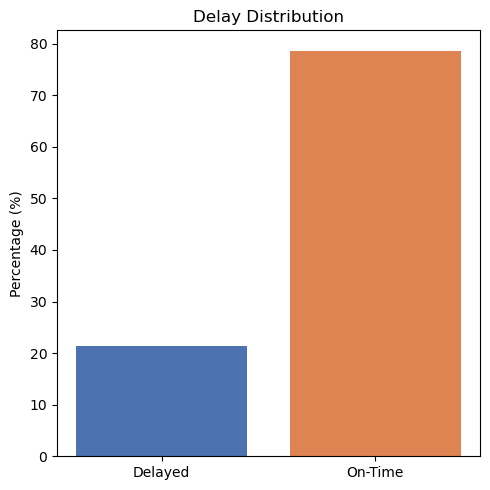


3. Delay Rate by Route (Top 10):
+----------------+-----------+-------------+-----------------+
|route_short_name|total_trips|delayed_trips| delay_percentage|
+----------------+-----------+-------------+-----------------+
|             499|       1803|         1364|75.65169162506933|
|             K12|        432|          320|74.07407407407408|
|              9a|       1409|         1011|71.75301632363377|
|             112|        726|          517|71.21212121212122|
|             643|        376|          266|70.74468085106383|
|              K4|       3770|         2646|70.18567639257294|
|             597|        648|          453| 69.9074074074074|
|            283A|       1935|         1347|69.61240310077518|
|             343|       3687|         2566|69.59587740710604|
|             562|       3976|         2763|69.49195171026157|
+----------------+-----------+-------------+-----------------+



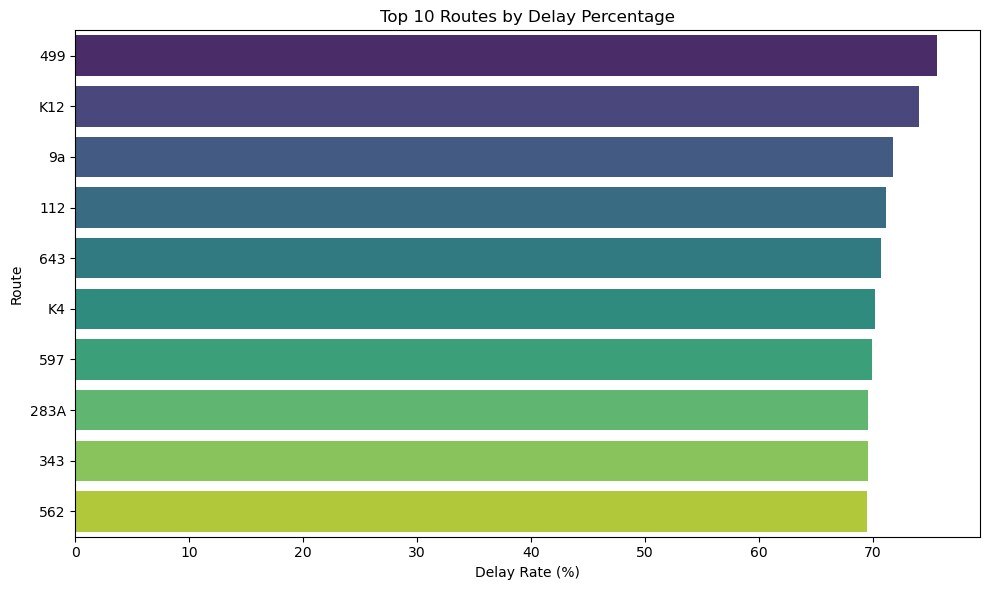


4. Delay Rate by Hour:
+------------+-----------+-------------+------------------+
|arrival_hour|total_trips|delayed_trips|  delay_percentage|
+------------+-----------+-------------+------------------+
|           0|        754|          182|24.137931034482758|
|           1|         43|            4|  9.30232558139535|
|           2|         69|           15| 21.73913043478261|
|           3|         67|           22| 32.83582089552239|
|           4|       9259|         1066|11.513122367426288|
|           5|      88551|        12970|14.646926629851723|
|           6|     200040|        32421|16.207258548290344|
|           7|     306007|        62006|20.262935161613953|
|           8|     366588|        85187|23.237803746985715|
|           9|     441249|        92926|  21.0597644413925|
|          10|     468552|        98939|21.115906025371782|
|          11|     471625|       101696|21.562894248608536|
|          12|     471483|       104151|22.090085962802476|
|          13|  

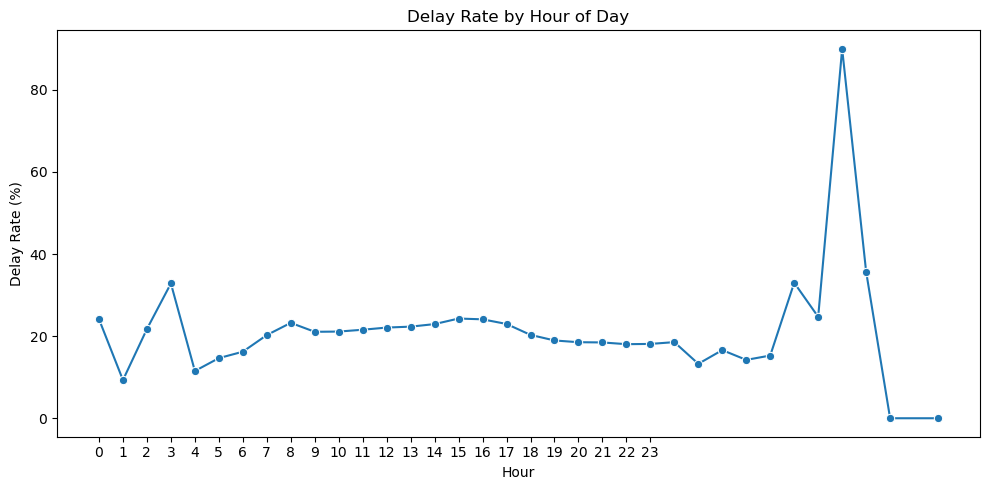


5. Delay in Peak vs Non-Peak Hours:
+------------+-----------+-------------+------------------+
|is_peak_hour|total_trips|delayed_trips|  delay_percentage|
+------------+-----------+-------------+------------------+
|           1|    2381804|       526234|22.093925444746922|
|           0|    4100032|       858081|20.928641532553893|
+------------+-----------+-------------+------------------+



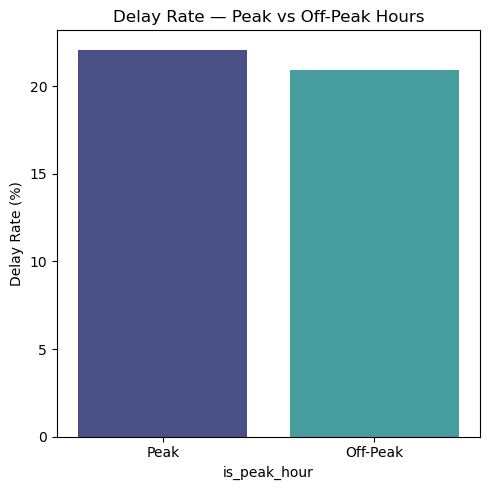


6. Feature Correlations:
Correlation Matrix:
                          stop_sequence  travel_time_to_prev_stop  \
stop_sequence                  1.000000                 -0.168392   
travel_time_to_prev_stop      -0.168392                  1.000000   
route_avg_travel_time         -0.297568                  0.257510   
stop_avg_travel_time          -0.166878                  0.902380   
is_delayed                    -0.005526                  0.665470   

                          route_avg_travel_time  stop_avg_travel_time  \
stop_sequence                         -0.297568             -0.166878   
travel_time_to_prev_stop               0.257510              0.902380   
route_avg_travel_time                  1.000000              0.264758   
stop_avg_travel_time                   0.264758              1.000000   
is_delayed                            -0.052137              0.511543   

                          is_delayed  
stop_sequence              -0.005526  
travel_time_to_prev_st

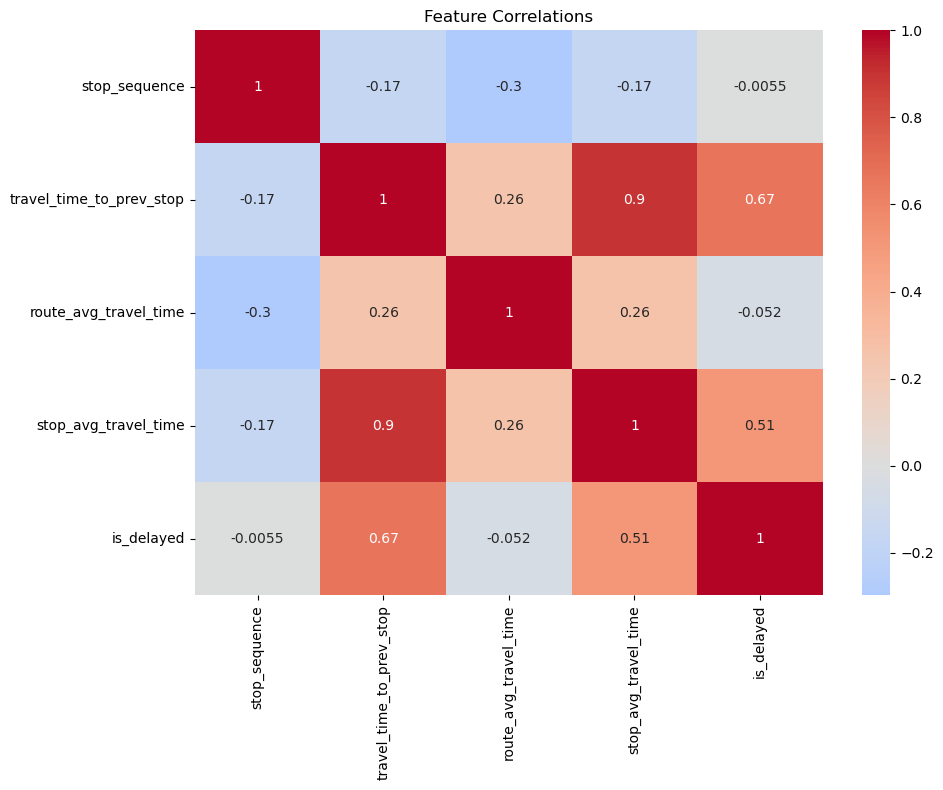


7. Distribution / Outlier Check (box plots):


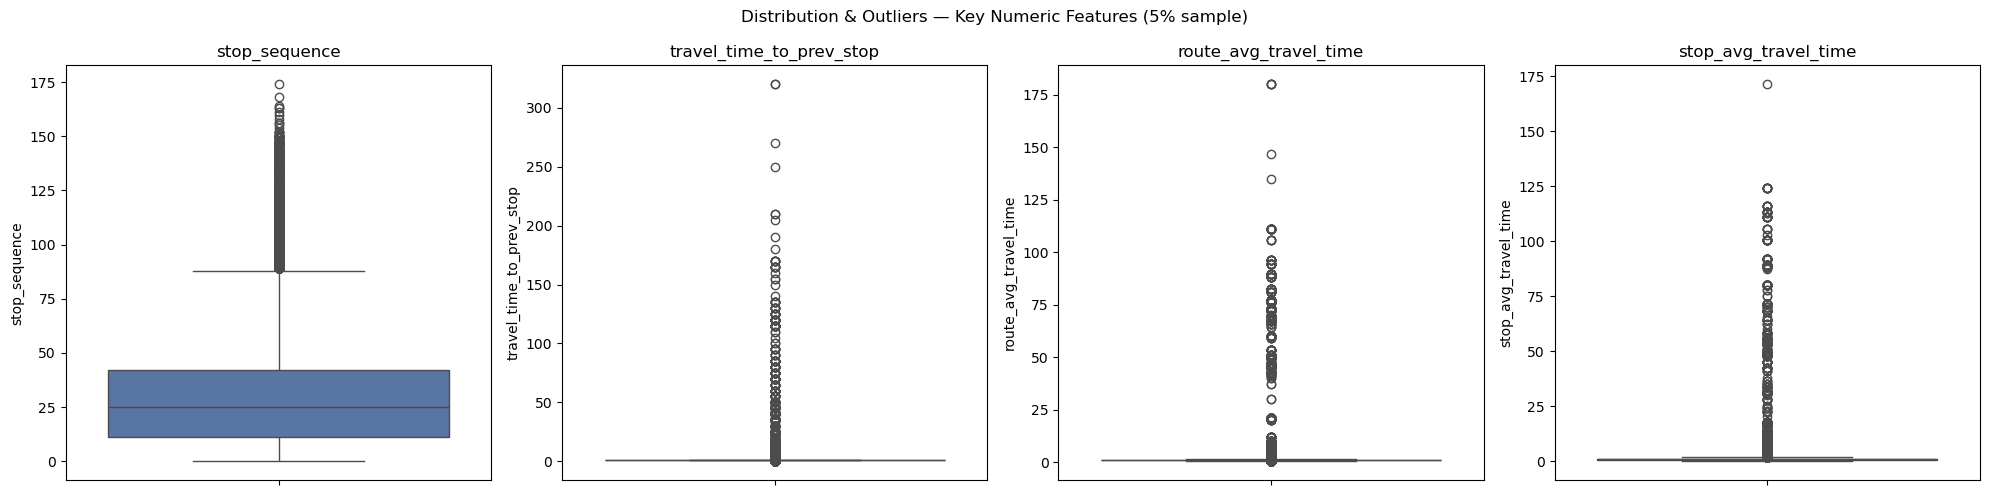

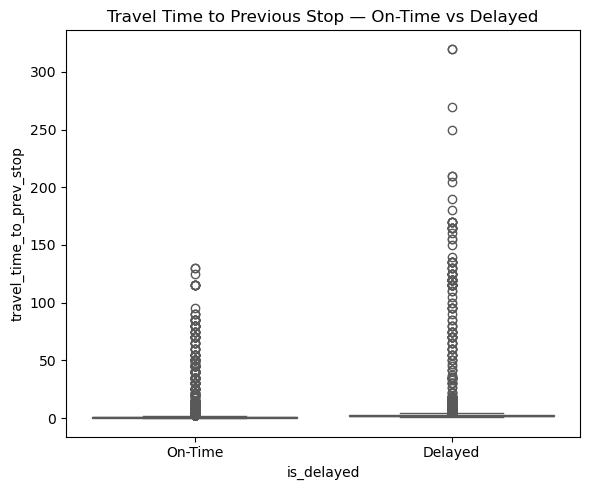

In [6]:
def perform_eda(df):
    print("\n" + "="*50)
    print("Exploratory Data Analysis")
    print("="*50)

    # ------------------------------------------------------------------
    # 1. Travel Time Statistics
    # ------------------------------------------------------------------
    print("\n1. Travel Time Statistics:")
    df.select('travel_time_to_prev_stop', 'route_avg_travel_time').describe().show()

    # ------------------------------------------------------------------
    # 2. Delay Distribution
    # ------------------------------------------------------------------
    print("\n2. Delay Distribution:")
    delay_dist = df.groupBy('is_delayed').count()
    total_count = df.count()
    delay_dist = delay_dist.withColumn('percentage', col('count') / lit(total_count) * 100)
    delay_dist.show()

    delay_dist_pd = delay_dist.toPandas()
    plt.figure(figsize=(5, 5))
    plt.bar(delay_dist_pd['is_delayed'].map({0: 'On-Time', 1: 'Delayed'}), delay_dist_pd['percentage'],
            color=['#4C72B0', '#DD8452'])
    plt.title("Delay Distribution")
    plt.ylabel("Percentage (%)")
    plt.tight_layout()
    plt.savefig("fig_delay_distribution.png", dpi=150)
    plt.show()

    # ------------------------------------------------------------------
    # 3. Delay Rate by Route (Top 10)
    # ------------------------------------------------------------------
    print("\n3. Delay Rate by Route (Top 10):")
    route_delay = df.groupBy('route_short_name').agg(
        count('*').alias('total_trips'),
        sum('is_delayed').alias('delayed_trips'),
        (sum('is_delayed') / count('*') * 100).alias('delay_percentage')
    ).orderBy(col('delay_percentage').desc()).limit(10)
    route_delay.show()

    route_delay_pd = route_delay.toPandas()
    plt.figure(figsize=(10, 6))
    sns.barplot(data=route_delay_pd, x='delay_percentage', y='route_short_name',
                hue='route_short_name', palette="viridis", legend=False)
    plt.title("Top 10 Routes by Delay Percentage")
    plt.xlabel("Delay Rate (%)")
    plt.ylabel("Route")
    plt.tight_layout()
    plt.savefig("fig_delay_by_route.png", dpi=150)
    plt.show()

    # ------------------------------------------------------------------
    # 4. Delay Rate by Hour
    # ------------------------------------------------------------------
    print("\n4. Delay Rate by Hour:")
    hour_delay = df.groupBy('arrival_hour').agg(
        count('*').alias('total_trips'),
        sum('is_delayed').alias('delayed_trips'),
        (sum('is_delayed') / count('*') * 100).alias('delay_percentage')
    ).orderBy('arrival_hour')
    hour_delay.show(24)

    hour_delay_pd = hour_delay.toPandas().sort_values('arrival_hour')
    plt.figure(figsize=(10, 5))
    sns.lineplot(data=hour_delay_pd, x='arrival_hour', y='delay_percentage', marker='o')
    plt.title("Delay Rate by Hour of Day")
    plt.xlabel("Hour")
    plt.ylabel("Delay Rate (%)")
    plt.xticks(range(0, 24))
    plt.tight_layout()
    plt.savefig("fig_delay_by_hour.png", dpi=150)
    plt.show()

    # ------------------------------------------------------------------
    # 5. Delay in Peak vs Non-Peak Hours
    # ------------------------------------------------------------------
    print("\n5. Delay in Peak vs Non-Peak Hours:")
    peak_delay = df.groupBy('is_peak_hour').agg(
        count('*').alias('total_trips'),
        sum('is_delayed').alias('delayed_trips'),
        (sum('is_delayed') / count('*') * 100).alias('delay_percentage'))
    peak_delay.show()

    peak_delay_pd = peak_delay.toPandas()
    peak_delay_pd['is_peak_hour'] = peak_delay_pd['is_peak_hour'].map({0: 'Off-Peak', 1: 'Peak'})
    plt.figure(figsize=(5, 5))
    sns.barplot(data=peak_delay_pd, x='is_peak_hour', y='delay_percentage',
                hue='is_peak_hour', palette="mako", legend=False)
    plt.title("Delay Rate — Peak vs Off-Peak Hours")
    plt.ylabel("Delay Rate (%)")
    plt.tight_layout()
    plt.savefig("fig_delay_peak_vs_offpeak.png", dpi=150)
    plt.show()

    # ------------------------------------------------------------------
    # 6. Feature Correlations
    # ------------------------------------------------------------------
    print("\n6. Feature Correlations:")
    numeric_cols = ['stop_sequence', 'travel_time_to_prev_stop', 'route_avg_travel_time', 'stop_avg_travel_time']
    sample_df = df.select(numeric_cols + ['is_delayed']).limit(10000).toPandas()
    if not sample_df.empty:
        correlation_matrix = sample_df.corr()
        print("Correlation Matrix:")
        print(correlation_matrix)
        plt.figure(figsize=(10, 8))
        sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
        plt.title('Feature Correlations')
        plt.tight_layout()
        plt.savefig('correlation_heatmap.png', dpi=300)
        plt.show()
    print("\n7. Distribution / Outlier Check (box plots):")
    box_sample = df.select(numeric_cols).sample(fraction=0.05, seed=42).toPandas()
    fig, axes = plt.subplots(1, len(numeric_cols), figsize=(20, 5))
    for ax, c in zip(axes, numeric_cols):
        sns.boxplot(y=box_sample[c], ax=ax, color="#4C72B0")
        ax.set_title(c)
    plt.suptitle("Distribution & Outliers — Key Numeric Features (5% sample)")
    plt.tight_layout()
    plt.savefig("fig_boxplots_numeric_features.png", dpi=150)
    plt.show()

    delay_box_sample = df.select('travel_time_to_prev_stop', 'is_delayed') \
        .sample(fraction=0.05, seed=42).toPandas()
    plt.figure(figsize=(6, 5))
    sns.boxplot(x='is_delayed', y='travel_time_to_prev_stop', hue='is_delayed',
                data=delay_box_sample, palette="Set2", legend=False)
    plt.xticks([0, 1], ["On-Time", "Delayed"])
    plt.title("Travel Time to Previous Stop — On-Time vs Delayed")
    plt.tight_layout()
    plt.savefig("fig_boxplot_traveltime_by_label.png", dpi=150)
    plt.show()

    return route_delay, hour_delay


route_delay, hour_delay = perform_eda(feature_df)

In [7]:
def prepare_ml_data(df):
    print("\n" + "="*50)
    print("Preparing Data for Machine Learning")
    print("="*50)
    feature_cols = ['stop_sequence', 'travel_time_to_prev_stop', 'route_avg_travel_time',
                     'stop_avg_travel_time', 'arrival_hour', 'is_peak_hour', 'stop_percentage']
    target_col = 'is_delayed'
    required_cols = feature_cols + ['route_short_name', target_col]
    df = df.dropna(subset=required_cols)
    print(f"Records after dropping nulls: {df.count():,}")

    categorical_cols = ['route_short_name']
    indexers = [StringIndexer(inputCol=c, outputCol=f"{c}_index", handleInvalid='keep') for c in categorical_cols]
    encoders = [OneHotEncoder(inputCol=f"{c}_index", outputCol=f"{c}_ohe") for c in categorical_cols]
    all_feature_cols = feature_cols + [f"{c}_ohe" for c in categorical_cols]

    assembler = VectorAssembler(inputCols=all_feature_cols, outputCol="features_vec", handleInvalid="skip")
    scaler = StandardScaler(inputCol="features_vec", outputCol="scaled_features")
    final_assembler = VectorAssembler(inputCols=["scaled_features"], outputCol="features", handleInvalid="skip")

    pipeline = Pipeline(stages=indexers + encoders + [assembler, scaler, final_assembler])
    ml_df = pipeline.fit(df).transform(df)
    final_df = ml_df.select('features', target_col)
    final_df = final_df.cache()

    print(f"ML data prepared: {final_df.count():,} records")
    print(f"Feature vector size: {final_df.select('features').first()[0].size}")
    return final_df, pipeline

ml_df, pipeline = prepare_ml_data(feature_df)


Preparing Data for Machine Learning
Records after dropping nulls: 6,343,400


[Stage 344:================================================>      (28 + 4) / 32]

ML data prepared: 6,343,400 records
Feature vector size: 863



Statistical Profiling (Skewness / Kurtosis / Outliers)

travel_time_to_prev_stop:
  Mean: 1.1619
  Std Dev: 2.8675
  Skewness: 39.0192  (right-skewed)
  Kurtosis: 2122.6749  (heavy-tailed)

route_avg_travel_time:
  Mean: 1.1802
  Std Dev: 2.5655
  Skewness: 30.6587  (right-skewed)
  Kurtosis: 1065.3135  (heavy-tailed)

stop_avg_travel_time:
  Mean: 1.1939
  Std Dev: 2.7312
  Skewness: 31.4372  (right-skewed)
  Kurtosis: 1397.2335  (heavy-tailed)

stop_sequence:
  Mean: 29.0286
  Std Dev: 21.9380
  Skewness: 0.9408  (right-skewed)
  Kurtosis: 0.8065  (heavy-tailed)

----------------------------------------
Outlier Detection (IQR method)
----------------------------------------
travel_time_to_prev_stop: Q1=1.00, Q3=1.00, IQR=0.00, bounds=[1.00, 1.00], outliers=2,586,076
route_avg_travel_time: Q1=0.94, Q3=1.17, IQR=0.23, bounds=[0.60, 1.51], outliers=312,142
stop_avg_travel_time: Q1=0.66, Q3=1.24, IQR=0.58, bounds=[-0.20, 2.11], outliers=521,549
stop_sequence: Q1=12.00, Q3=42.00, IQR=30.

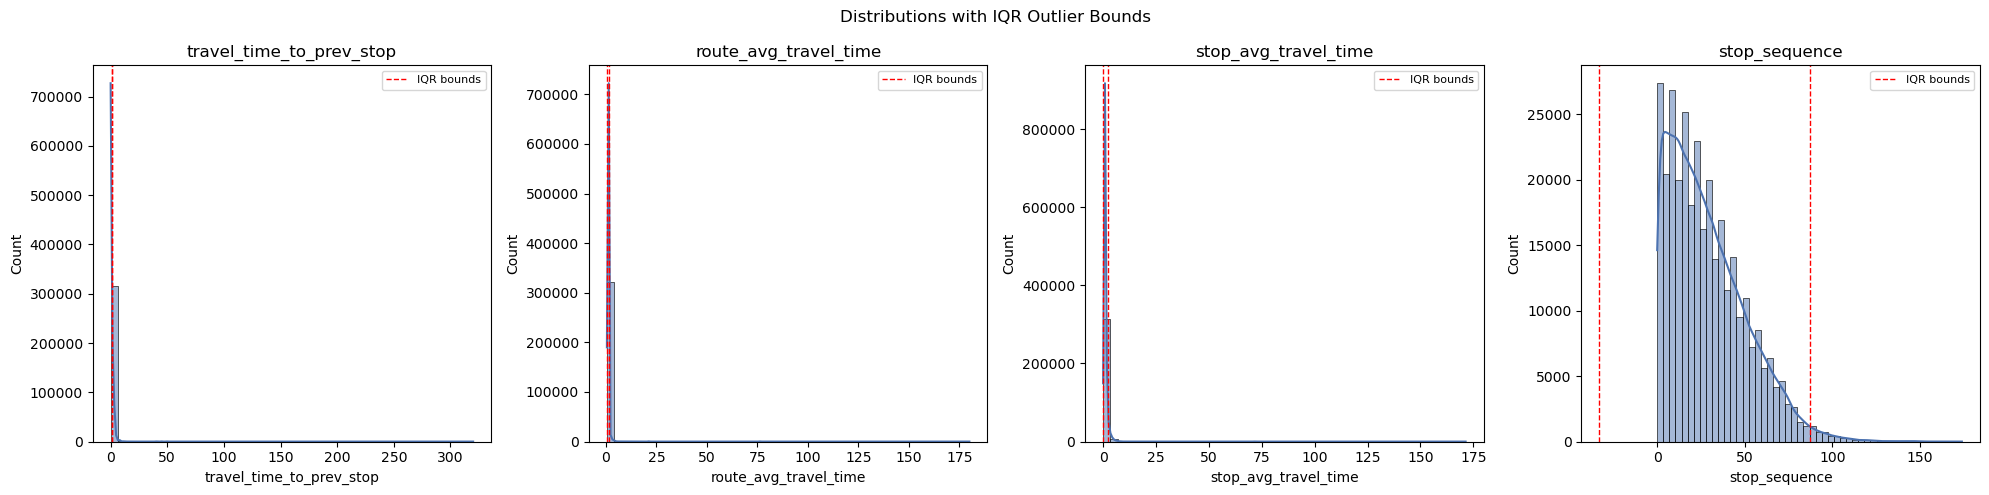

In [8]:
def statistical_profile(df, numeric_cols):
    """
    Calculate skewness, kurtosis, and outlier bounds using PySpark functions
    """
    print("\n" + "="*50)
    print("Statistical Profiling (Skewness / Kurtosis / Outliers)")
    print("="*50)

    agg_exprs = []
    for c in numeric_cols:
        agg_exprs += [
            mean(col(c)).alias(f"{c}_mean"),
            stddev(col(c)).alias(f"{c}_std"),
            skewness(col(c)).alias(f"{c}_skew"),
            kurtosis(col(c)).alias(f"{c}_kurt"),
        ]

    stats_row = df.select(agg_exprs).collect()[0]

    for c in numeric_cols:
        print(f"\n{c}:")
        print(f"  Mean: {stats_row[f'{c}_mean']:.4f}")
        print(f"  Std Dev: {stats_row[f'{c}_std']:.4f}")
        print(f"  Skewness: {stats_row[f'{c}_skew']:.4f}  "
              f"({'right-skewed' if stats_row[f'{c}_skew'] > 0 else 'left-skewed'})")
        print(f"  Kurtosis: {stats_row[f'{c}_kurt']:.4f}  "
              f"({'heavy-tailed' if stats_row[f'{c}_kurt'] > 0 else 'light-tailed'})")

    # Outlier detection using IQR method (native PySpark, no UDF needed)
    print("\n" + "-"*40)
    print("Outlier Detection (IQR method)")
    print("-"*40)
    for c in numeric_cols:
        quantiles = df.approxQuantile(c, [0.25, 0.75], 0.01)
        if len(quantiles) == 2 and quantiles[0] is not None:
            q1, q3 = quantiles
            iqr = q3 - q1
            lower_bound = q1 - 1.5 * iqr
            upper_bound = q3 + 1.5 * iqr
            outlier_count = df.filter((col(c) < lower_bound) | (col(c) > upper_bound)).count()
            print(f"{c}: Q1={q1:.2f}, Q3={q3:.2f}, IQR={iqr:.2f}, "
                  f"bounds=[{lower_bound:.2f}, {upper_bound:.2f}], outliers={outlier_count:,}")
            
    sample_pd = df.select(numeric_cols).sample(fraction=0.05, seed=42).toPandas()
    fig, axes = plt.subplots(1, len(numeric_cols), figsize=(20, 5))
    for ax, c in zip(axes, numeric_cols):
        sns.histplot(sample_pd[c].dropna(), bins=50, kde=True, ax=ax, color="#4C72B0")
        q1, q3 = df.approxQuantile(c, [0.25, 0.75], 0.01)
        iqr = q3 - q1
        lower_bound, upper_bound = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        ax.axvline(lower_bound, color='red', linestyle='--', linewidth=1, label='IQR bounds')
        ax.axvline(upper_bound, color='red', linestyle='--', linewidth=1)
        ax.set_title(c)
        ax.legend(fontsize=8)
    plt.suptitle("Distributions with IQR Outlier Bounds")
    plt.tight_layout()
    plt.savefig("fig_distributions_with_outlier_bounds.png", dpi=150)
    plt.show()

    return stats_row


numeric_cols_to_profile = ['travel_time_to_prev_stop', 'route_avg_travel_time',
                            'stop_avg_travel_time', 'stop_sequence']
stats_result = statistical_profile(feature_df, numeric_cols_to_profile)


############################################################
# LEAKAGE CHECK: comparing F1 with vs without stop_avg_travel_time
############################################################

Preparing Data for Machine Learning
Using feature_cols: ['stop_sequence', 'stop_avg_travel_time', 'arrival_hour', 'is_peak_hour', 'stop_percentage']
Records after dropping nulls: 6,458,708


ML data prepared: 6,458,708 records
Feature vector size: 861


26/07/26 20:58:13 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
                                                                                

[WITH stop_avg_travel_time] Logistic Regression F1: 0.8596

Preparing Data for Machine Learning
Using feature_cols: ['stop_sequence', 'arrival_hour', 'is_peak_hour', 'stop_percentage']
Records after dropping nulls: 6,481,836


ML data prepared: 6,481,836 records
Feature vector size: 860


[WITHOUT stop_avg_travel_time] Logistic Regression F1: 0.7504

F1 gap: 0.1092
=> Meaningful gap: stop_avg_travel_time is likely contributing some leakage.
   Recommend dropping it, or reporting this gap explicitly in Critical Reflection.


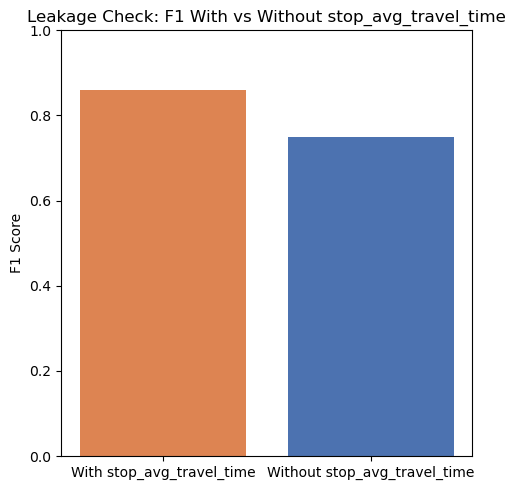


Preparing Data for Machine Learning
Using feature_cols: ['stop_sequence', 'arrival_hour', 'is_peak_hour', 'stop_percentage']
Records after dropping nulls: 6,481,836


[Stage 1373:===============================================>      (28 + 4) / 32]

ML data prepared: 6,481,836 records
Feature vector size: 860


In [9]:
# ============================================
# 7. MACHINE LEARNING PIPELINE - PREPARE DATA
# ============================================
def prepare_ml_data(df, feature_cols):
    
    print("\n" + "="*50)
    print("Preparing Data for Machine Learning")
    print("="*50)
    print(f"Using feature_cols: {feature_cols}")
 
    target_col = 'is_delayed'
    required_cols = feature_cols + ['route_short_name', target_col]
    df = df.dropna(subset=required_cols)
    print(f"Records after dropping nulls: {df.count():,}")
 
    categorical_cols = ['route_short_name']
    indexers = [StringIndexer(inputCol=c, outputCol=f"{c}_index", handleInvalid='keep')
                for c in categorical_cols]
    encoders = [OneHotEncoder(inputCol=f"{c}_index", outputCol=f"{c}_ohe")
                for c in categorical_cols]
 
    all_feature_cols = feature_cols + [f"{c}_ohe" for c in categorical_cols]
 
    assembler = VectorAssembler(inputCols=all_feature_cols, outputCol="features_vec", handleInvalid="skip")
    scaler = StandardScaler(inputCol="features_vec", outputCol="scaled_features")
    final_assembler = VectorAssembler(inputCols=["scaled_features"], outputCol="features", handleInvalid="skip")
 
    pipeline = Pipeline(stages=indexers + encoders + [assembler, scaler, final_assembler])
 
    ml_df = pipeline.fit(df).transform(df)
    final_df = ml_df.select('features', target_col)
    final_df = final_df.cache()
 
    print(f"ML data prepared: {final_df.count():,} records")
    print(f"Feature vector size: {final_df.select('features').first()[0].size}")
 
    return final_df, pipeline
 
 
# ============================================
# 7b. LEAKAGE CHECK — with vs without stop_avg_travel_time
# ============================================
def quick_f1_check(ml_df, label_name):
    """Fast single-model (Logistic Regression) F1 check — not the full 3-model
    comparison, just enough to see whether a feature set is suspiciously strong."""
    train_df, test_df = ml_df.randomSplit([0.8, 0.2], seed=42)
    lr = LogisticRegression(labelCol="is_delayed", featuresCol="features", maxIter=50)
    model = lr.fit(train_df)
    pred = model.transform(test_df)
    f1 = MulticlassClassificationEvaluator(
        labelCol="is_delayed", predictionCol="prediction", metricName="f1"
    ).evaluate(pred)
    print(f"[{label_name}] Logistic Regression F1: {f1:.4f}")
    return f1
 
feature_cols_with_stop_avg = [
    'stop_sequence', 'stop_avg_travel_time', 'arrival_hour', 'is_peak_hour', 'stop_percentage'
]
feature_cols_without_stop_avg = [
    'stop_sequence', 'arrival_hour', 'is_peak_hour', 'stop_percentage'
]
 
print("\n" + "#"*60)
print("# LEAKAGE CHECK: comparing F1 with vs without stop_avg_travel_time")
print("#"*60)
 
ml_df_with, _ = prepare_ml_data(feature_df, feature_cols_with_stop_avg)
f1_with = quick_f1_check(ml_df_with, "WITH stop_avg_travel_time")
 
ml_df_without, _ = prepare_ml_data(feature_df, feature_cols_without_stop_avg)
f1_without = quick_f1_check(ml_df_without, "WITHOUT stop_avg_travel_time")
 
gap = f1_with - f1_without
print(f"\nF1 gap: {gap:.4f}")
if gap > 0.05:
    print("=> Meaningful gap: stop_avg_travel_time is likely contributing some leakage.")
    print("   Recommend dropping it, or reporting this gap explicitly in Critical Reflection.")
else:
    print("=> Small gap: stop_avg_travel_time is probably fine to keep as a feature,")
    print("   but still worth a one-line mention of the risk in your report.")
 
# ------------------------------------------------------------------
# Plot: F1 comparison bar chart (visual evidence for the report)
# ------------------------------------------------------------------
plt.figure(figsize=(5, 5))
plt.bar(['With stop_avg_travel_time', 'Without stop_avg_travel_time'],
        [f1_with, f1_without], color=['#DD8452', '#4C72B0'])
plt.ylabel("F1 Score")
plt.ylim(0, 1)
plt.title("Leakage Check: F1 With vs Without stop_avg_travel_time")
plt.tight_layout()
plt.savefig("fig_leakage_check_f1_comparison.png", dpi=150)
plt.show()
ml_df, pipeline = prepare_ml_data(feature_df, feature_cols_without_stop_avg) 


Training and Comparing Models


Training set: 5,185,223


Test set: 1,296,613


Subsampled training set for tree models: 1,036,746

----------------------------------------
1. Logistic Regression
----------------------------------------



----------------------------------------
2. Random Forest
----------------------------------------



----------------------------------------
3. Gradient Boosted Trees
----------------------------------------



Logistic Regression:
  Accuracy:  0.8001
  Precision: 0.7705
  Recall:    0.8001
  F1 Score:  0.7504
  AUC-ROC:   0.6656



Random Forest:
  Accuracy:  0.7864
  Precision: 0.6185
  Recall:    0.7864
  F1 Score:  0.6924
  AUC-ROC:   0.6064



GBT:
  Accuracy:  0.7909
  Precision: 0.7571
  Recall:    0.7909
  F1 Score:  0.7146
  AUC-ROC:   0.6445

Best Model: Logistic Regression (F1=0.7504)


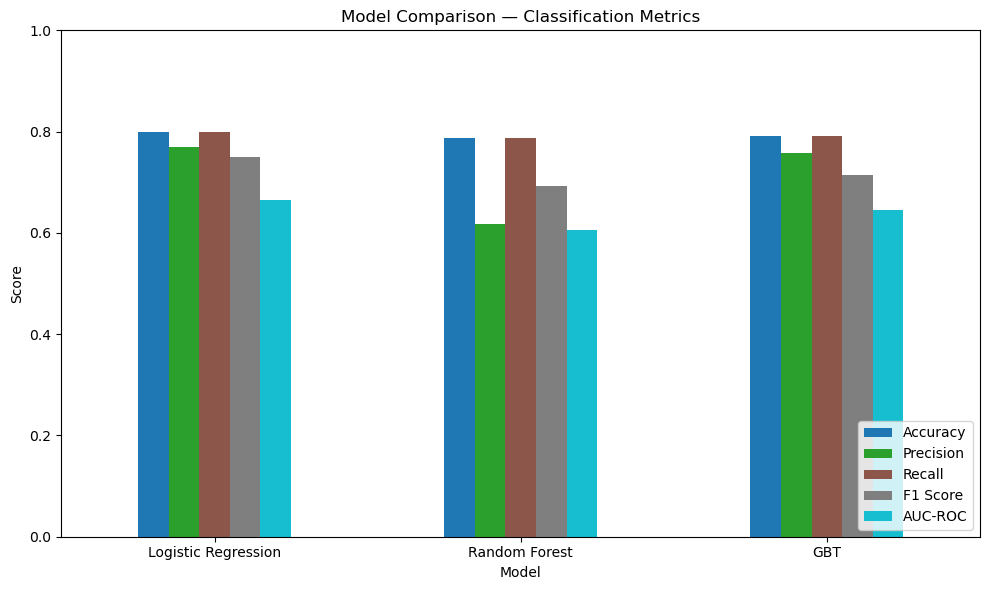

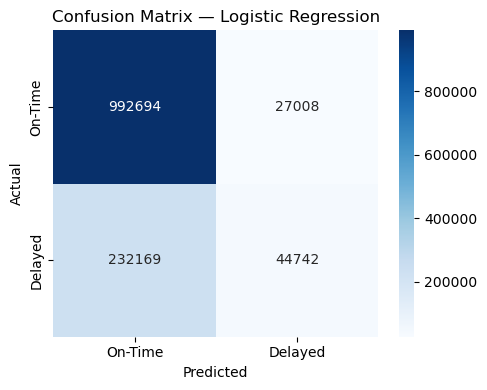

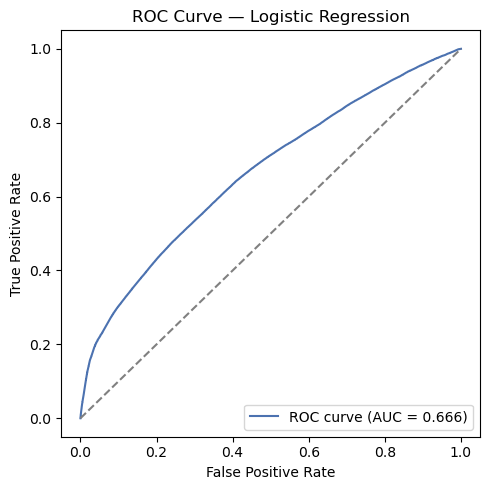


Model Comparison Summary
Logistic Regression: Acc=0.8001, Prec=0.7705, Rec=0.8001, F1=0.7504, AUC=0.6656
Random Forest: Acc=0.7864, Prec=0.6185, Rec=0.7864, F1=0.6924, AUC=0.6064
GBT: Acc=0.7909, Prec=0.7571, Rec=0.7909, F1=0.7146, AUC=0.6445


In [10]:
# ============================================
# 8. MODEL TRAINING AND COMPARISON (FULL METRICS)
# ============================================
import builtins
from sklearn.metrics import confusion_matrix, roc_curve, auc as sk_auc
from pyspark.ml.functions import vector_to_array

def train_and_compare_models(ml_df):
   
    print("\n" + "="*50)
    print("Training and Comparing Models")
    print("="*50)

    train_df, test_df = ml_df.randomSplit([0.8, 0.2], seed=42)
    print(f"Training set: {train_df.count():,}")
    print(f"Test set: {test_df.count():,}")

    train_df_sampled = train_df.sample(fraction=0.2, seed=42).cache()
    sampled_count = train_df_sampled.count()
    print(f"Subsampled training set for tree models: {sampled_count:,}")

    print("\n" + "-"*40)
    print("1. Logistic Regression")
    print("-"*40)
    lr = LogisticRegression(labelCol="is_delayed", featuresCol="features", maxIter=100)
    lr_model = lr.fit(train_df)
    lr_pred = lr_model.transform(test_df)

    print("\n" + "-"*40)
    print("2. Random Forest")
    print("-"*40)
    rf = RandomForestClassifier(labelCol="is_delayed", featuresCol="features", numTrees=20, maxDepth=5)
    rf_model = rf.fit(train_df_sampled)
    rf_pred = rf_model.transform(test_df)

    print("\n" + "-"*40)
    print("3. Gradient Boosted Trees")
    print("-"*40)
    gbt = GBTClassifier(labelCol="is_delayed", featuresCol="features", maxIter=15, maxDepth=4)
    gbt_model = gbt.fit(train_df_sampled)
    gbt_pred = gbt_model.transform(test_df)

    # Full metric set required by the brief: Accuracy, Precision, Recall, F1, ROC-AUC
    evaluator_f1 = MulticlassClassificationEvaluator(labelCol="is_delayed", predictionCol="prediction", metricName="f1")
    evaluator_accuracy = MulticlassClassificationEvaluator(labelCol="is_delayed", predictionCol="prediction", metricName="accuracy")
    evaluator_precision = MulticlassClassificationEvaluator(labelCol="is_delayed", predictionCol="prediction", metricName="weightedPrecision")
    evaluator_recall = MulticlassClassificationEvaluator(labelCol="is_delayed", predictionCol="prediction", metricName="weightedRecall")
    evaluator_auc = BinaryClassificationEvaluator(labelCol="is_delayed", rawPredictionCol="rawPrediction", metricName="areaUnderROC")

    results = []
    models = {'Logistic Regression': lr_model, 'Random Forest': rf_model, 'GBT': gbt_model}

    for name, pred in [('Logistic Regression', lr_pred), ('Random Forest', rf_pred), ('GBT', gbt_pred)]:
        f1 = evaluator_f1.evaluate(pred)
        acc = evaluator_accuracy.evaluate(pred)
        prec = evaluator_precision.evaluate(pred)
        rec = evaluator_recall.evaluate(pred)
        auc = evaluator_auc.evaluate(pred)

        print(f"\n{name}:")
        print(f"  Accuracy:  {acc:.4f}")
        print(f"  Precision: {prec:.4f}")
        print(f"  Recall:    {rec:.4f}")
        print(f"  F1 Score:  {f1:.4f}")
        print(f"  AUC-ROC:   {auc:.4f}")

        results.append({
            'Model': name, 'Accuracy': acc, 'Precision': prec,
            'Recall': rec, 'F1 Score': f1, 'AUC-ROC': auc
        })

    best_result = builtins.max(results, key=lambda r: r['F1 Score'])
    best_model = models[best_result['Model']]
    print(f"\nBest Model: {best_result['Model']} (F1={best_result['F1 Score']:.4f})")

    # ------------------------------------------------------------------
    # Plot: model comparison bar chart
    # ------------------------------------------------------------------
    results_pd = pd.DataFrame(results).set_index('Model')
    results_pd[['Accuracy', 'Precision', 'Recall', 'F1 Score', 'AUC-ROC']].plot(
        kind='bar', figsize=(10, 6), colormap="tab10"
    )
    plt.title("Model Comparison — Classification Metrics")
    plt.ylabel("Score")
    plt.ylim(0, 1)
    plt.xticks(rotation=0)
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.savefig("fig_model_comparison.png", dpi=150)
    plt.show()

    # ------------------------------------------------------------------
    # Plot: confusion matrix for best model
    # ------------------------------------------------------------------
    best_pred = best_model.transform(test_df)
    cm_pd = best_pred.select('is_delayed', 'prediction').toPandas()
    cm = confusion_matrix(cm_pd['is_delayed'], cm_pd['prediction'])
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['On-Time', 'Delayed'], yticklabels=['On-Time', 'Delayed'])
    plt.title(f"Confusion Matrix — {best_result['Model']}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.savefig("fig_confusion_matrix.png", dpi=150)
    plt.show()

    # ------------------------------------------------------------------
    # Plot: ROC curve for best model
    # ------------------------------------------------------------------
    prob_pd = best_pred.select(
        'is_delayed',
        vector_to_array('probability')[1].alias('prob_delayed')
    ).toPandas()
    fpr, tpr, _ = roc_curve(prob_pd['is_delayed'], prob_pd['prob_delayed'])
    roc_auc_val = sk_auc(fpr, tpr)
    plt.figure(figsize=(5, 5))
    plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc_val:.3f})", color="#4C72B0")
    plt.plot([0, 1], [0, 1], linestyle='--', color='grey')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve — {best_result['Model']}")
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.savefig("fig_roc_curve.png", dpi=150)
    plt.show()

    return results, best_model, test_df


model_results, best_model, test_df = train_and_compare_models(ml_df)

print("\n" + "="*50)
print("Model Comparison Summary")
print("="*50)
for result in model_results:
    print(f"{result['Model']}: Acc={result['Accuracy']:.4f}, Prec={result['Precision']:.4f}, "
          f"Rec={result['Recall']:.4f}, F1={result['F1 Score']:.4f}, AUC={result['AUC-ROC']:.4f}")